# Generate the test images

Generates every synthetic image of `synthetic_images_2D.GENERATORS`, 32-bit float in
$[0, 1]$, and saves them in this folder as `synthetic_<name>_<size>.tif`. The default
size is $N = 512$ pixels; `SIZES` holds the exceptions (`chirp` at $1024$).

The real image `collagen.tif` is not generated: it is a real acquisition of collagen fibers
stored in this folder. The processing notebooks
[1](../orientationj_python_port/analysis.ipynb) / [2](../orientationj_python_port/distribution.ipynb) / [3](../orientationj_python_port/vector_field.ipynb)
load all these files from disk.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import synthetic_images_2D as sim

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
})

In [2]:
images = {}
for name, generator in sim.GENERATORS.items():
    images[name] = generator(sim.SIZES.get(name, sim.N))

for name in images:
    path = sim.save(images[name], name)
    print('saved', path, ' ', images[name].shape)

saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_chirp_1024.tif   (1024, 1024)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_wave_512.tif   (512, 512)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_spiral_512.tif   (512, 512)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_rings_dither_512.tif   (512, 512)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_noise_512.tif   (512, 512)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_filaments_512.tif   (512, 512)
saved /Users/dsage/Desktop/dev/OrientationJ/orientationj-test-images/synthetic_nematic_512.tif   (512, 512)


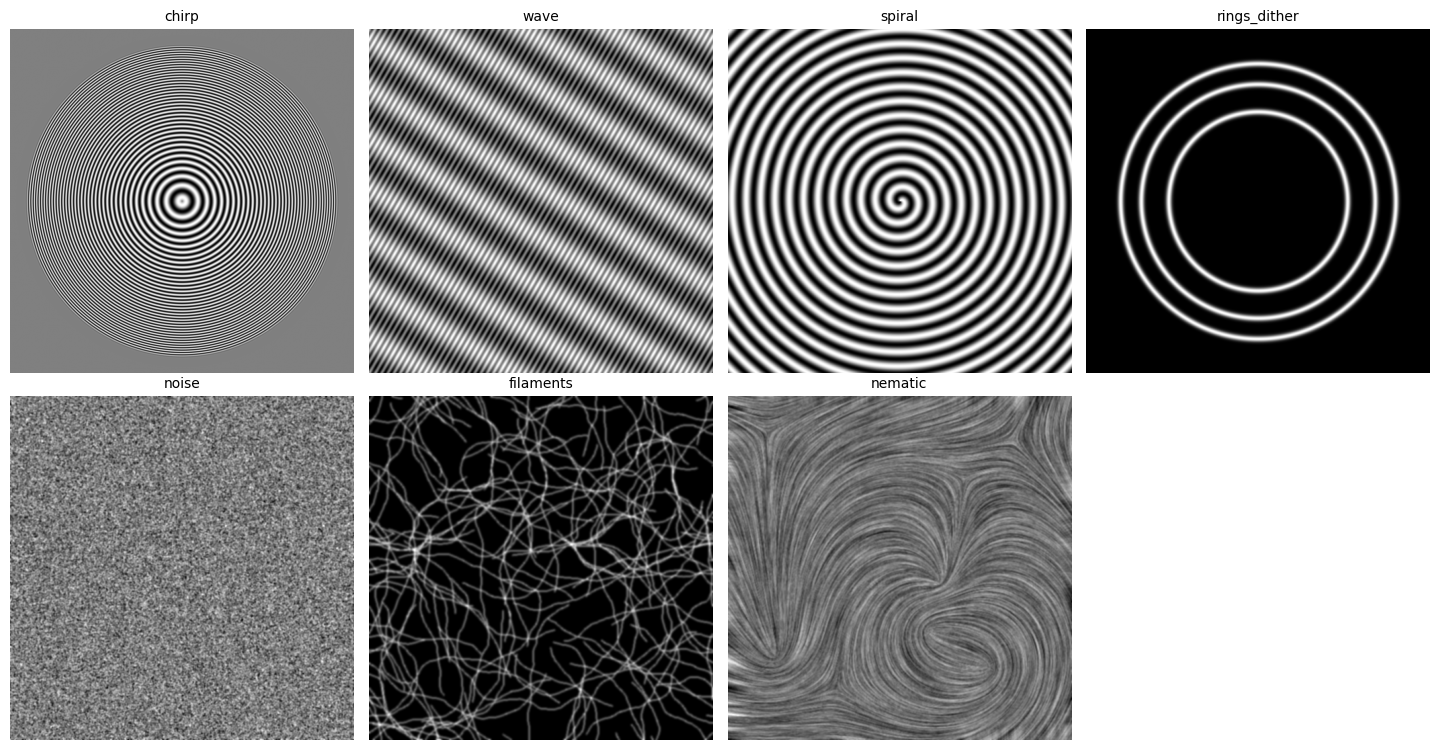

In [3]:
names = list(images.keys())
fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.6))
for ax in axes.ravel():
    ax.axis('off')
for index in range(len(names)):
    ax = axes[index // 4][index % 4]
    ax.imshow(images[names[index]], cmap='gray')
    ax.set_title(names[index])
fig.tight_layout()
plt.show()

All images are square, 32-bit float in $[0, 1]$: $512 × 512$ except `chirp` at
$1024 × 1024$. `wave` is the superposition of two waves of equal amplitude, with different
orientations (fringes at $+60°$ and $-30°$) and very different periods (8 and 64 pixels);
`rings_dither` is a few full rings around the center with a Gaussian radial profile, plus an
invisible dither ($σ = 10^{-4}$) that breaks the exact central symmetry of the pattern —
without it, the orientation distribution shows artificial spikes at exactly $0$, $±45$ and
$±90$ degrees.